# EPMT Data "Cleanup" - Next 1, 2, 3

Following up from EPMTDataCleanup.ipynb
1. Try without group information
2. Maybe not needing script_name AND exp_name -- too correlated (likely) - Taking out script_name and keeping exp_name
3. bronx-23 --- try this one only

With this data, we're trying just a bunch of models on it to see what happens.
1. LinearRegressor
2. DecisionTree
3. RandomForest
4. Boosting
5. Multi-Layer Perceptron
6. Voting Ensemble

Best R-squared was .44 --- not too great

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import ast
from datetime import datetime

%matplotlib inline 

# Suggested by Gemini -- "Makes your plots look a bit more modern/clean"
sns.set_theme(style="whitegrid")

# Load some data and revisit what we have so far

In [3]:
import glob
import os

data_path = 'epmt_data_cleaned_20260311_152213.csv'

df = pd.read_csv(data_path)

In [4]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'minflt',
 'majflt',
 'SLURM_NTASKS',
 'exp_time',
 'exp_seg_months',
 'SLURM_JOB_ACCOUNT_cefi',
 'SLURM_JOB_ACCOUNT_gfdl_a',
 'SLURM_JOB_ACCOUNT_gfdl_b',
 'SLURM_JOB_ACCOUNT_gfdl_f',
 'SLURM_JOB_ACCOUNT_gfdl_m',
 'SLURM_JOB_ACCOUNT_gfdl_o',
 'SLURM_JOB_ACCOUNT_gfdl_sd',
 'SLURM_JOB_ACCOUNT_gfdl_w',
 'SLURM_SCRIPT_CONTEXT_prolog_task',
 'LOADEDMODULES_epmt/4.9.2',
 'LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2',
 'LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2',
 'LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/202

In [5]:
df = df.dropna() # TODO: How do I have NaNs?

len(df)

39998

In [6]:
df.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,exp_time,exp_seg_months,...,script_name_pjk_atmos,script_name_proto4_0,script_name_proto4_c48l33o1degSPEAR,script_name_sak_atmos,script_name_tk_atmos,script_name_van_ch4,script_name_van_mon,script_name_van_o3analysis,script_name_wheeler_kiladis,script_name_yim_aer
count,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000,...,39998.000000,39998.000000,39998.000000,39998.000000,39998.00000,39998.000000,39998.000000,39998.000000,39998.000000,39998.000000
mean,19.639942,22.116564,21.980580,18.345402,19.639561,15.372211,3.894671,0.999200,14.701985,10.647757,...,0.002675,0.017201,0.000775,0.002675,0.00275,0.001250,0.004900,0.002450,0.000450,0.000500
std,4.907657,3.511290,1.514159,1.864823,1.633097,1.657386,2.727799,0.040614,2.603295,3.705366,...,0.051653,0.130021,0.027829,0.051653,0.05237,0.035335,0.069831,0.049439,0.021209,0.022356
min,4.550452,14.452213,17.873178,13.681440,15.476442,11.295988,0.000000,0.000000,7.591798,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.176407,20.615549,20.917242,17.072184,18.565143,14.188742,1.386294,1.000000,13.122567,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19.852722,22.415513,22.004250,18.105225,19.670361,15.351910,4.158883,1.000000,16.091762,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.926759,24.724435,22.946620,19.559413,20.624165,16.362734,5.966147,1.000000,16.809747,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,29.686951,29.497051,25.990648,23.290917,23.712838,19.624009,12.837526,2.000000,16.827613,12.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                            1.000000
duration                            0.893648
minflt                              0.857371
write_bytes                         0.825490
time_waiting                        0.767144
                                      ...   
exp_component_analysis             -0.137374
exp_fre_mod_Missing                -0.137374
exp_name_SPEAR_c96                 -0.159634
script_name_SPEAR_c96              -0.159634
SLURM_SCRIPT_CONTEXT_prolog_task         NaN
Name: cpu_time, Length: 223, dtype: float64

# Opps. Let's take out what we won't have at training time, like duration, minflt, etc.

In [8]:
target = 'cpu_time'
y = df[target]

X = df.drop(target, axis=1)
X = X.drop('duration', axis=1)
X = X.drop('time_waiting', axis=1)
X = X.drop('read_bytes', axis=1)
X = X.drop('write_bytes', axis=1)
X = X.drop('minflt', axis=1)
X = X.drop('majflt', axis=1)

df.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                            1.000000
duration                            0.893648
minflt                              0.857371
write_bytes                         0.825490
time_waiting                        0.767144
                                      ...   
exp_component_analysis             -0.137374
exp_fre_mod_Missing                -0.137374
exp_name_SPEAR_c96                 -0.159634
script_name_SPEAR_c96              -0.159634
SLURM_SCRIPT_CONTEXT_prolog_task         NaN
Name: cpu_time, Length: 223, dtype: float64

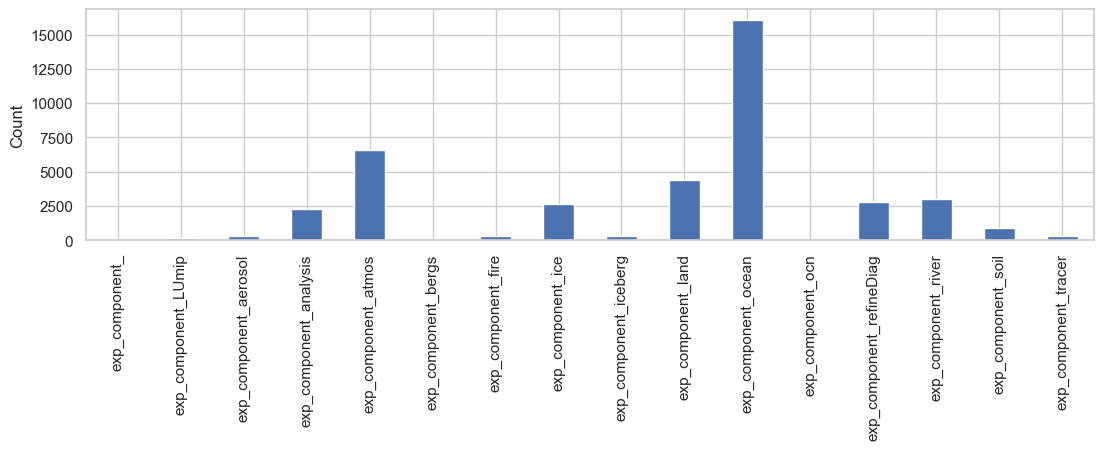

In [9]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(13,3))
    plt.ylabel('Count')
    plt.show()
    
plot_one_category(df, "exp_component")

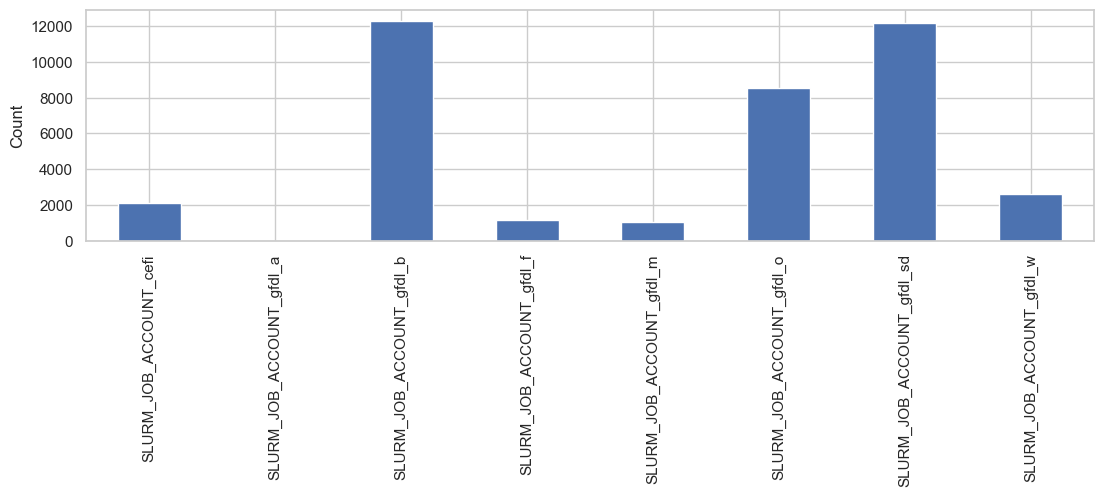

In [10]:
plot_one_category(df, "SLURM_JOB_ACCOUNT")

In [11]:
def drop_one_category(df, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df.columns if c.startswith(startswith)]
    return df.drop(cols, axis=1)

df = drop_one_category(df, "SLURM_JOB_ACCOUNT")

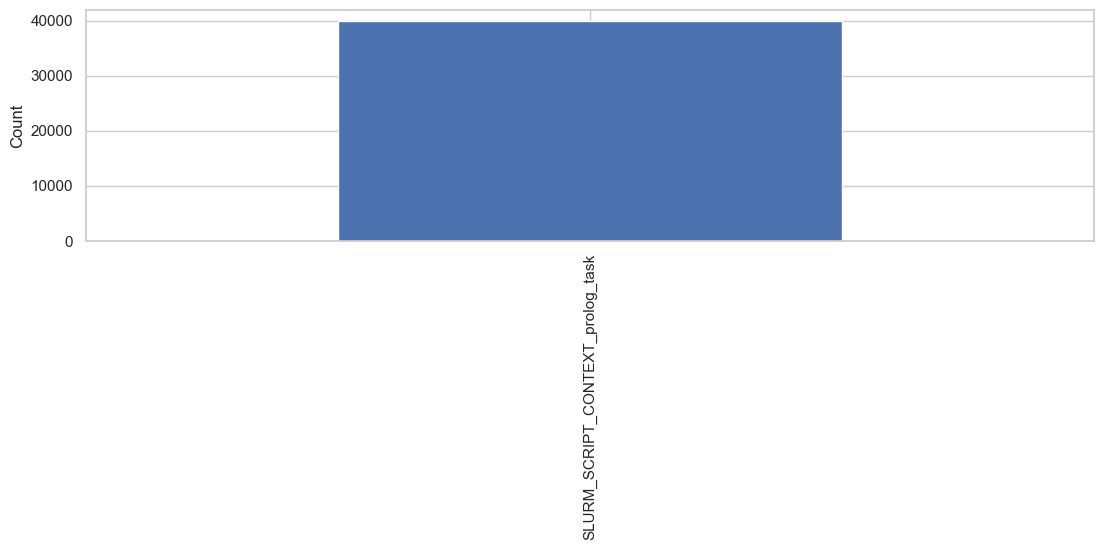

In [12]:
plot_one_category(df, "SLURM_SCRIPT_CONTEXT")

In [13]:
df = drop_one_category(df, "SLURM_SCRIPT_CONTEXT")

In [14]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'minflt',
 'majflt',
 'SLURM_NTASKS',
 'exp_time',
 'exp_seg_months',
 'LOADEDMODULES_epmt/4.9.2',
 'LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2',
 'LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2',
 'LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/2024.2.1:libpng/1.6.39:ncview/2.1.9:epmt/4.9.2',
 'LOADEDMODULES_python/3.9-pyferret:epmt/4.9.2',
 'exp_component_',
 'exp_component_LUmip',
 'exp_component_aerosol',
 'exp_component_analysis',
 'exp_component_atmos',
 'exp_component_bergs',
 'exp_component_fire',
 'exp_

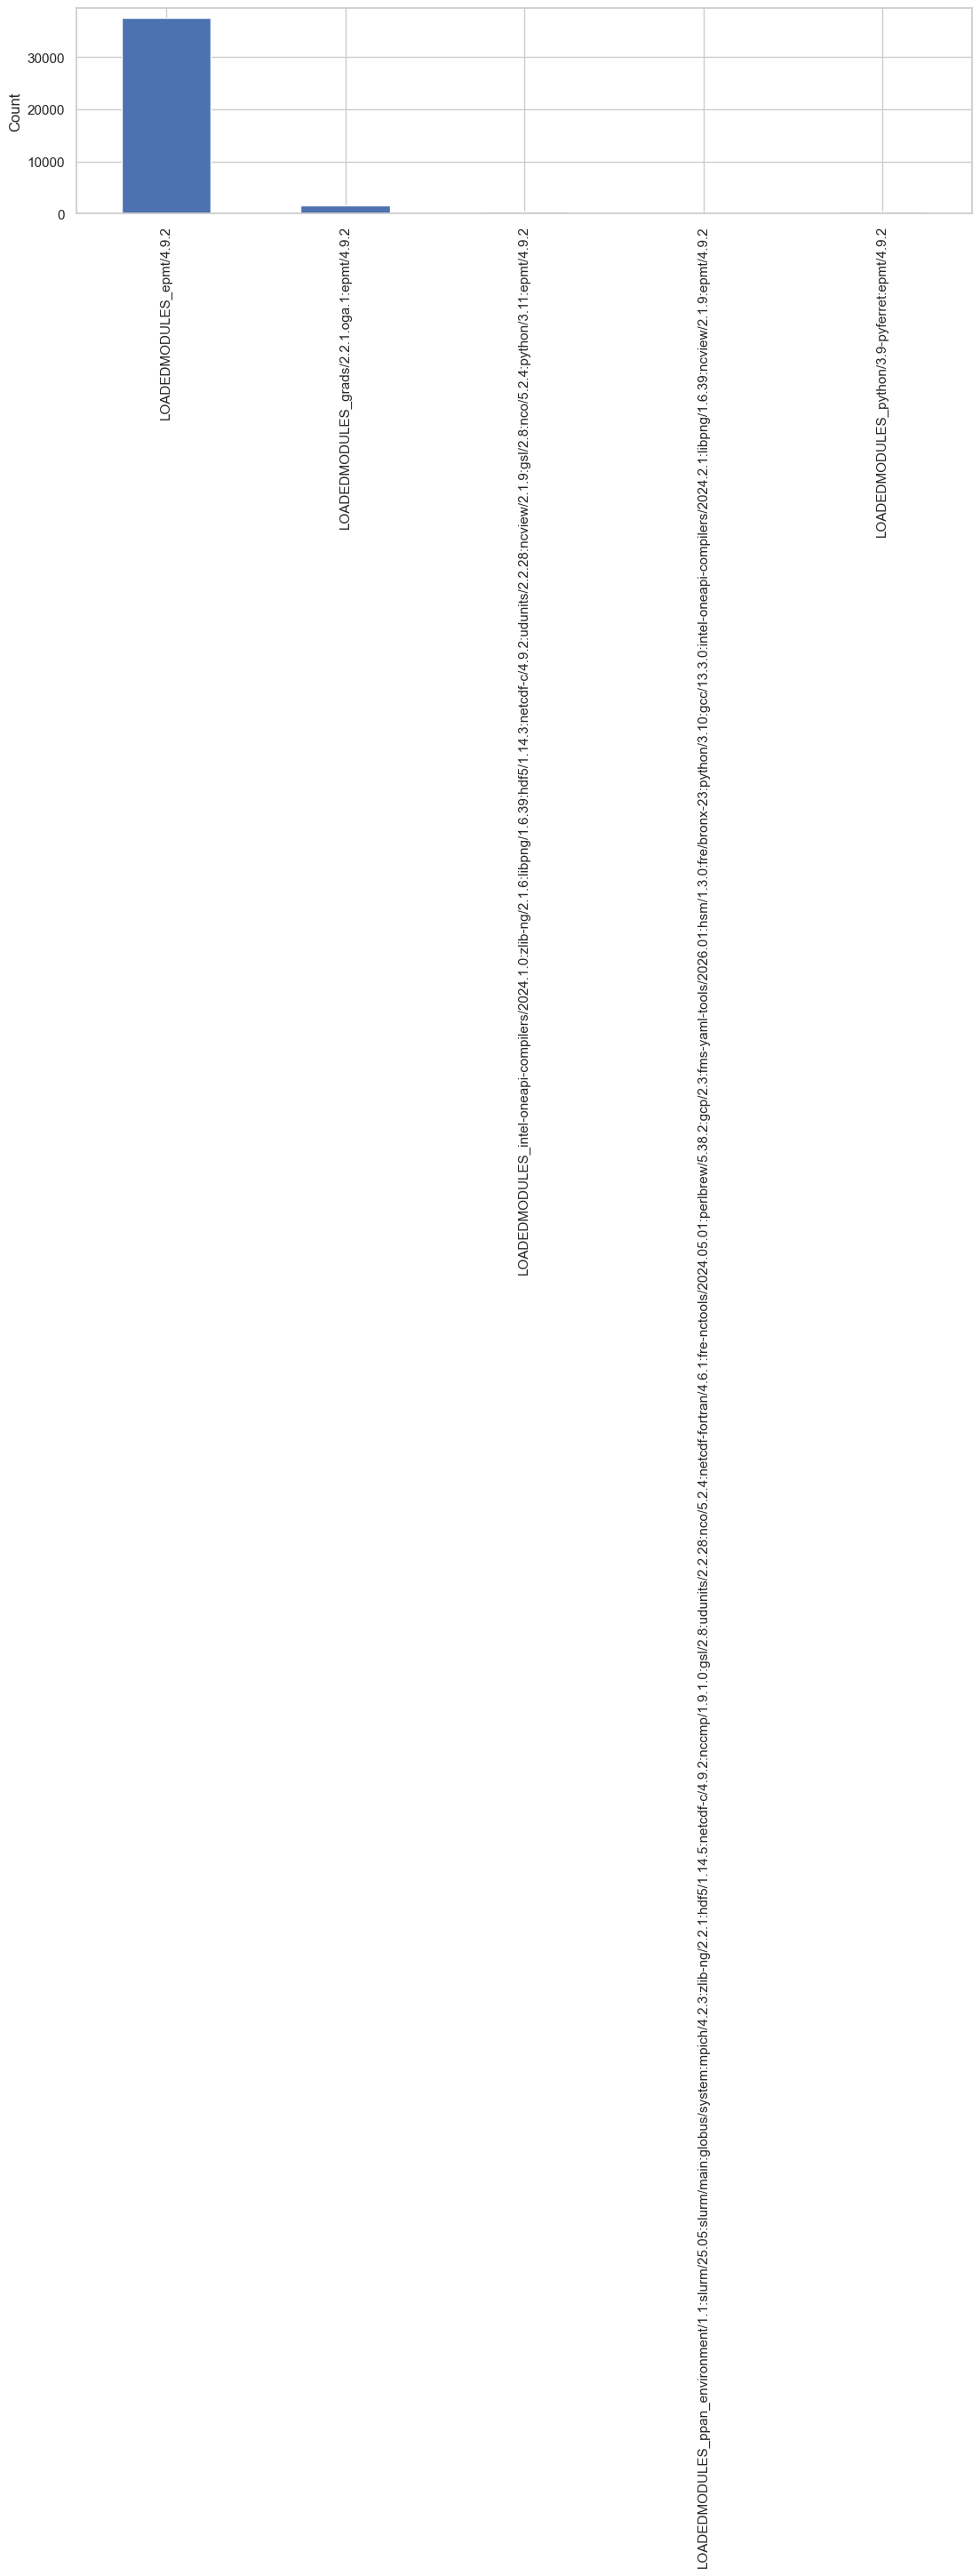

In [15]:
plot_one_category(df, "LOADEDMODULES")

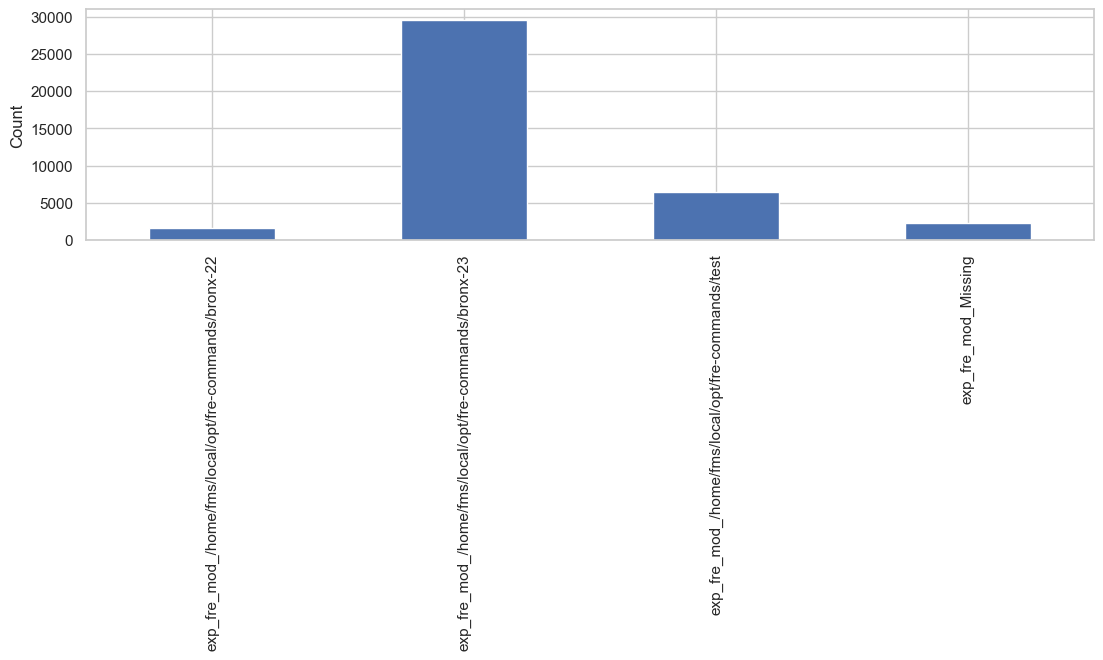

In [16]:
plot_one_category(df, "exp_fre_mod")

In [17]:
def drop_one_category_keep_substring(df, single_category, substring):
    startswith = f"{single_category}_" 
    df_filtered = df.copy()
    
    for c in df.columns:
        if c.startswith(startswith):
            if substring not in c:
                df_filtered = df_filtered.drop(c, axis=1)
            else:
                df_filtered = df[df[c] == 1]
                df_fittered = df_filtered.drop(c, axis=1)
    return df_filtered
df = drop_one_category_keep_substring(df, "exp_fre_mod", "bronx-23")
print(len(df))
df.columns.tolist()

29512


['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'minflt',
 'majflt',
 'SLURM_NTASKS',
 'exp_time',
 'exp_seg_months',
 'LOADEDMODULES_epmt/4.9.2',
 'LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2',
 'LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2',
 'LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/2024.2.1:libpng/1.6.39:ncview/2.1.9:epmt/4.9.2',
 'LOADEDMODULES_python/3.9-pyferret:epmt/4.9.2',
 'exp_component_',
 'exp_component_LUmip',
 'exp_component_aerosol',
 'exp_component_analysis',
 'exp_component_atmos',
 'exp_component_bergs',
 'exp_component_fire',
 'exp_

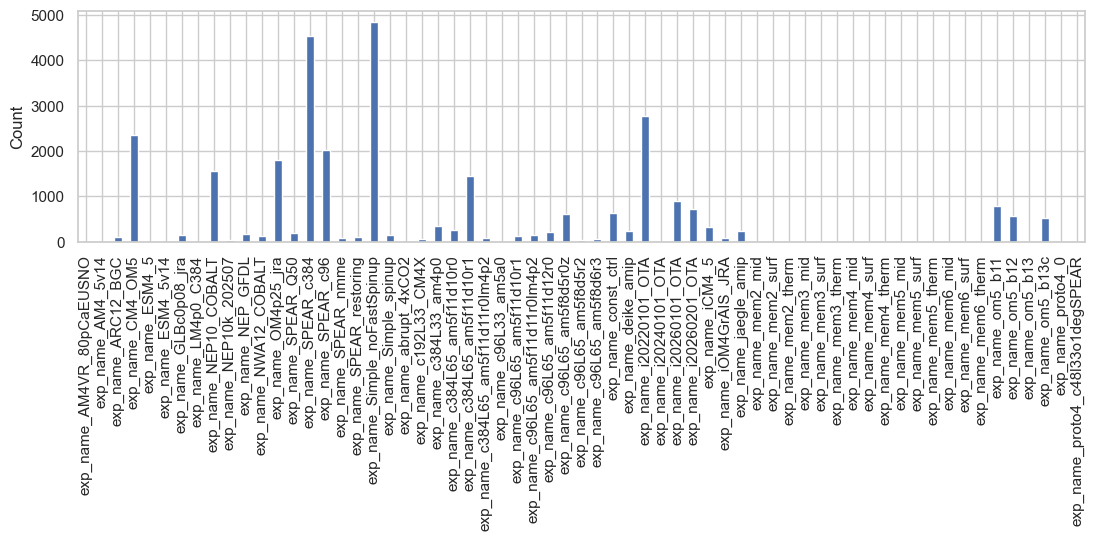

In [18]:
plot_one_category(df, "exp_name")

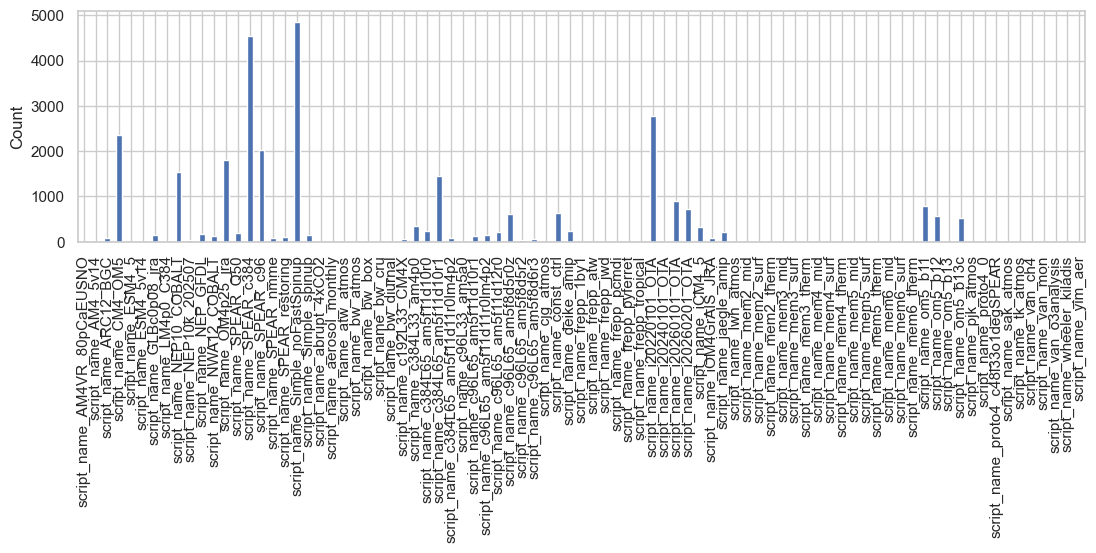

In [19]:
plot_one_category(df, "script_name")
df = drop_one_category(df, "script_name")

In [20]:
df = df.drop(columns=['duration', 'time_waiting', 'read_bytes', 'write_bytes', 'minflt', 'majflt'])
df.head()

,cpu_time,SLURM_NTASKS,exp_time,exp_seg_months,LOADEDMODULES_epmt/4.9.2,LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2,LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2,LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/2024.2.1:libpng/1.6.39:ncview/2.1.9:epmt/4.9.2,LOADEDMODULES_python/3.9-pyferret:epmt/4.9.2,exp_component_,...,exp_target_test12_01_20_2026,exp_target_test12_02_02_2026,exp_target_test13_01_20_2026,exp_target_test13_02_02_2026,exp_target_test14_01_20_2026,exp_target_test15_01_20_2026,exp_target_test16_01_20_2026,exp_target_test16_01_29_2026,exp_target_test8_02_02_2026,exp_target_test9_02_02_2026
0,19.315824,1.0,12.874164,12,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20.519708,1.0,12.874164,12,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18.079300,1.0,12.874164,12,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,16.571821,1.0,12.874164,12,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,19.514315,1.0,12.874164,12,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 121
# category columns: 0


In [22]:
df.columns.tolist()

['cpu_time',
 'SLURM_NTASKS',
 'exp_time',
 'exp_seg_months',
 'LOADEDMODULES_epmt/4.9.2',
 'LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2',
 'LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2',
 'LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/2024.2.1:libpng/1.6.39:ncview/2.1.9:epmt/4.9.2',
 'LOADEDMODULES_python/3.9-pyferret:epmt/4.9.2',
 'exp_component_',
 'exp_component_LUmip',
 'exp_component_aerosol',
 'exp_component_analysis',
 'exp_component_atmos',
 'exp_component_bergs',
 'exp_component_fire',
 'exp_component_ice',
 'exp_component_iceberg',
 'exp_component_land',
 'exp_component_oc

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [24]:
target = 'cpu_time'
df = df.dropna() # TODO: How do I have NaNs?
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 2.07
R-squared Score: 0.32


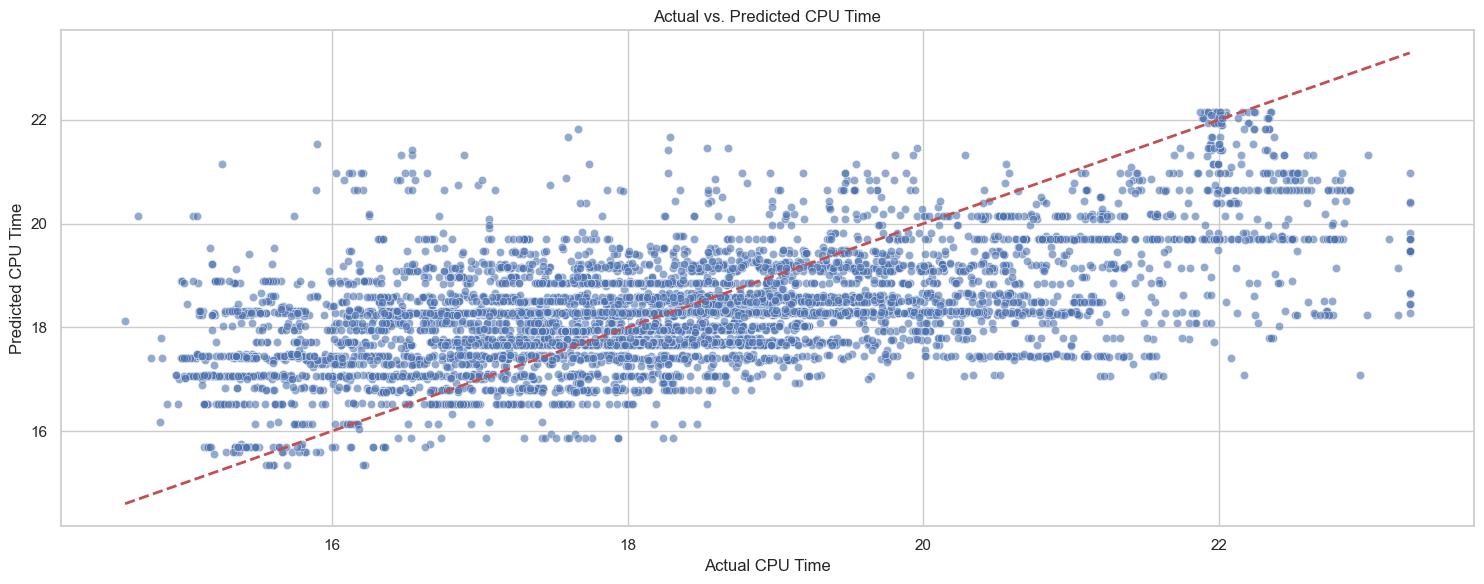

In [27]:
# TODO Code for the following was generated by Gemini. It will be inspected more carefully... eventually.

# Set the visual style
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_test, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title('Actual vs. Predicted CPU Time')
ax1.set_xlabel('Actual CPU Time')
ax1.set_ylabel('Predicted CPU Time')

plt.tight_layout()
plt.show()

In [28]:
df = df.dropna() # TODO: How do I have NaNs?
df.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                                   1.000000
exp_component_atmos                        0.334424
exp_name_c384L65_am5f11d10r1               0.321322
exp_platform_gfdl.ncrc5-intel23-classic    0.274655
exp_platform_gfdl.ncrc5-deploy             0.226938
                                             ...   
exp_name_proto4_c48l33o1degSPEAR                NaN
exp_platform_gfdl.intel15                       NaN
exp_platform_gfdl.ncrc5-intel22                 NaN
exp_platform_gfdl.ncrc6-intel23_2_0             NaN
exp_platform_gfdl.ncrc6-intel25                 NaN
Name: cpu_time, Length: 121, dtype: float64

In [29]:
target = 'cpu_time'
df = df.dropna() # TODO: How do I have NaNs?
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
from sklearn.tree import DecisionTreeRegressor

# TODO max_depth: too high leads to overfitting, too low to underfitting.
dtr_model = DecisionTreeRegressor(max_depth=15)
dtr_model.fit(X_train, y_train)

predictions = dtr_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.7939
R-squared Score: 0.41


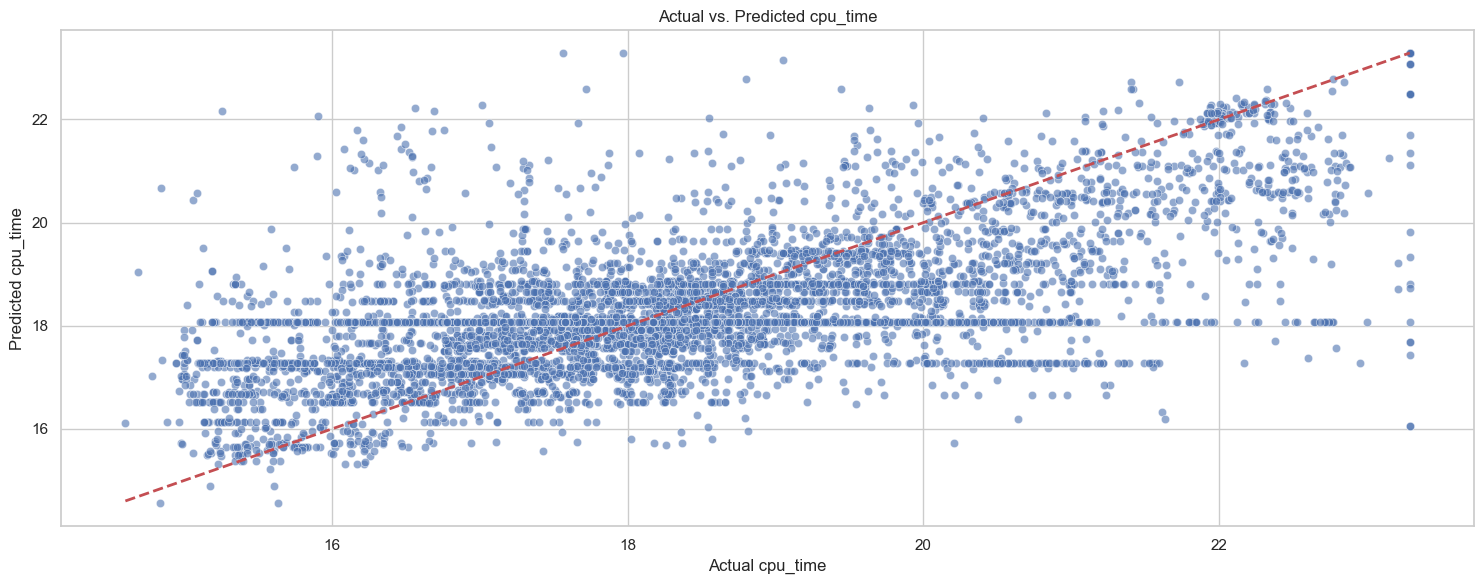

In [31]:
# TODO Code for the following was generated by Gemini. It will be inspected more carefully... eventually.

# Set the visual style
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_test, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

## Bagging vs Boosting
* Multiple models independent of eachother, average voting
* Multiple models trained sequentially, weighted voting

https://www.geeksforgeeks.org/machine-learning/bagging-vs-boosting-in-machine-learning/

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=5, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.7554
R-squared Score: 0.42


In [33]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html
from sklearn.ensemble import HistGradientBoostingRegressor
gb_model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, max_depth=25)
gb_model.fit(X_train, y_train)
predictions = gb_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.6936
R-squared Score: 0.44


In [34]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(15, 15), max_iter=75, random_state=42)
)
mlp_model.fit(X_train, y_train)
predictions = mlp_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.7949
R-squared Score: 0.41


In [35]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor(estimators=[
    ('rf', rf_model), 
    ('dtr', dtr_model), 
    ('lr', model),
    ('gb', gb_model),
    ('mlp', mlp_model)
])
ensemble.fit(X_train, y_train)
predictions = ensemble.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.7049
R-squared Score: 0.44


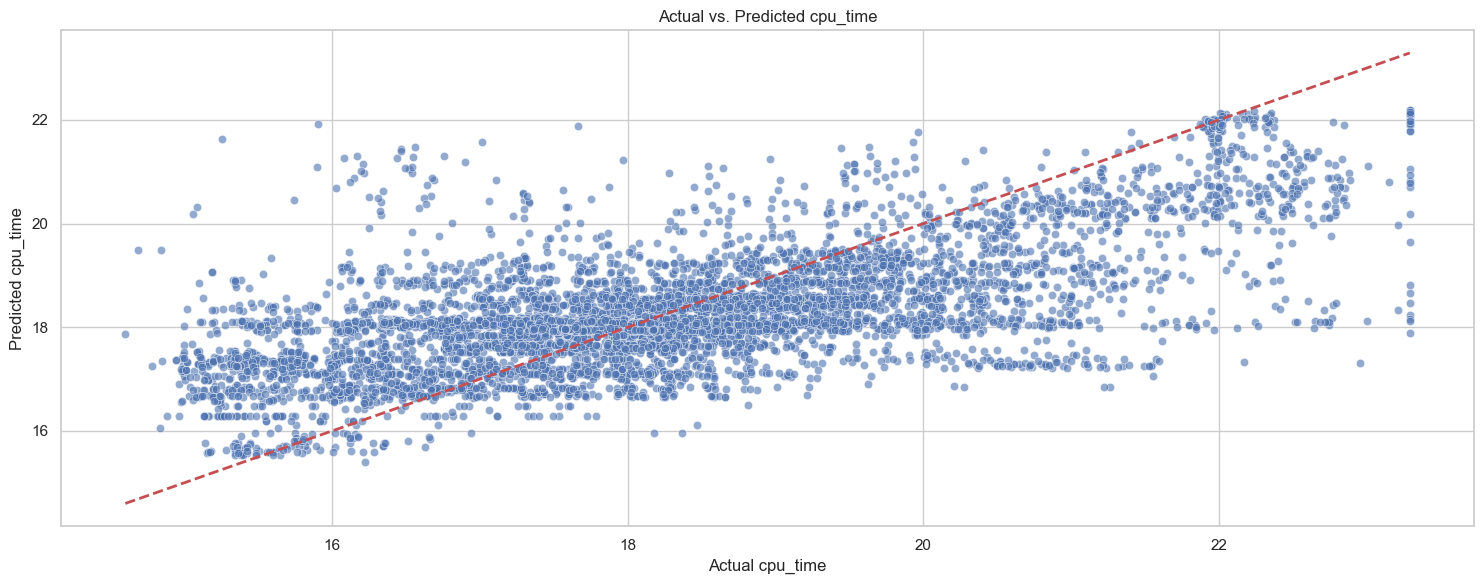

In [36]:
# TODO Code for the following was generated by Gemini. It will be inspected more carefully... eventually.

# Set the visual style
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_test, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

In [37]:
# Possible next steps ---
# TODO: 4. maybe try break up "ocean" exp_component --- even further... 
# TODO: 5. idea -- try starting from a small set of features -- comparison with above graph
# TODO: 6. More Hyper-parameter tuning
# TODO: 7. Try GridSearchCV? Example from Gemini below:

#from sklearn.model_selection import GridSearchCV
#
#param_grid = {
#    'n_estimators': [50, 100, 200],
#    'max_depth': [None, 10, 20],
#    'min_samples_split': [2, 5, 10]
#}
#
#grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='r2')
#grid_search.fit(X_train, y_train)
#
#print(f"Best R-squared from Grid Search: {grid_search.best_score_:.4f}")